In [1]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
)
from src.plotting import (
    make_animation,
    plot
)
from src.analysis.classifiers import classify_temporal_behavior
import plotly.express as px
import plotly.graph_objects as go
from dotenv import load_dotenv
from skimage import measure

In [3]:
model = "bruss"
ds_id = "final"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR")
df = ds.df
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]
df = classify_temporal_behavior(df, 0.1, 1, 0)
# df = df[df.A > 1]

In [15]:
df.category.unique()

array(['SS', 'OSC', 'DSS'], dtype=object)

In [7]:
ind = np.array([2560,    5, 7853, 4542, 5956, 7856, 6740, 9414, 7384, 2244, 3214,
       8259,  750, 1750, 7292, 3876, 3513, 2025,  613, 4697, 8691, 7425,
       2074, 1051, 6434, 4157,   39, 2413, 7018, 7725, 2000, 4105,  398,
       3102, 2817, 4192, 7736, 8421, 3837, 9816, 5521, 6838,   69,  911,
       5153, 4568, 4299, 8800,  268, 7327,  602, 4606, 9494, 5038, 1525,
       5865, 6373, 4522, 2843,  190, 6626, 6332, 9878,  710, 6973, 5682,
       8282, 4658, 5559, 6566, 6294, 4469, 7181, 3816, 9858, 1999, 8878,
       8243, 3304, 4709, 6139, 1557, 6814, 2308, 6310, 1554, 9143, 8369,
        756, 8155, 9056, 3713, 3965, 9790, 3407, 2387, 4965, 8668, 1807,
       6396,  199, 3676, 6319, 9929, 1369, 2787, 3265, 1339, 6418, 3983,
       1236, 7863, 7964,  309, 8580, 2200,  424, 6919, 6877, 6649, 6581,
        917, 2265, 4601, 6203, 4752, 8449, 5335, 5218, 4797, 6159, 4691,
       8175, 1854, 6413, 5109, 4635, 1955,  832, 3388, 4823, 2276, 2076,
       2656, 5340, 9089,  434, 5327, 4016, 2383, 4815, 7157, 9045, 6843,
       8775, 3073, 8264, 2139, 3572,  316, 4727,  252,  943, 9652, 8110,
       2725, 3005,  185, 1029, 8138,  843, 3291,   82, 3897, 1271,  401,
       5076,  208, 9541, 4272, 3706, 8128, 1573, 2610, 6727, 8127, 1689,
       8789, 2703, 7480,  135, 9648, 8268, 2040, 2322, 6000, 6969,  156,
       2806, 2663])

In [10]:
sub = df[df.idx.isin(ind)]

In [11]:
# df["q"] = np.power(df.A,2) / np.power(np.sqrt(df.B) - 1,2)
# df_sub = df[(df.A < 1) & (df.ratio_b_a.between(2,3)) & (df.q < 40)]
fig = px.scatter_3d(
    sub,
    x="A",
    y="ratio_b_a",
    z="mean_deviation", 
    color="category", 
    hover_data={"idx": True},
    color_continuous_scale=px.colors.sequential.Bluered,
)
fig.update_traces(marker_size=5)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0)
)
# x_vals = np.linspace(df_sub['A'].min(), df_sub['A'].max(), 400)
# y_vals = np.linspace(df_sub['ratio_b_a'].min(), df_sub['ratio_b_a'].max(), 400)
# X, Y = np.meshgrid(x_vals, y_vals)
# Z = X**2 / (np.sqrt(X*Y) - 1) **2 - 9

# contours = measure.find_contours(Z, level=0)
# for contour in contours:
#     # Convert contour pixel coords to data coords
#     contour_x = x_vals[contour[:, 1].astype(int)]
#     contour_y = y_vals[contour[:, 0].astype(int)]
#     contour_z = np.zeros_like(contour_x)

#     fig.add_trace(go.Scatter3d(
#         x=contour_x,
#         y=contour_y,
#         z=contour_z,
#         mode='lines',
#         line=dict(color='black', width=4),
#         name='Phase transition boundary'
#     ))

fig.show()

In [6]:
len(df[df.mean_dt > 10]), len(df)

(1198, 2000)

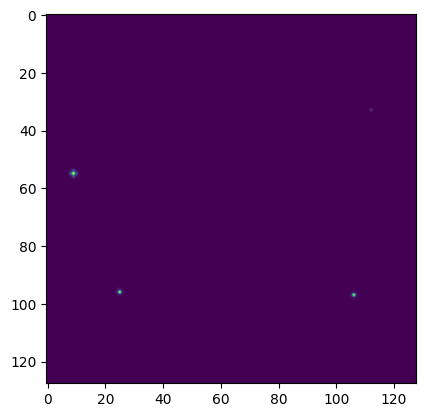

In [13]:
d = ds.get_data(1877)
plt.imshow(d[1,0])

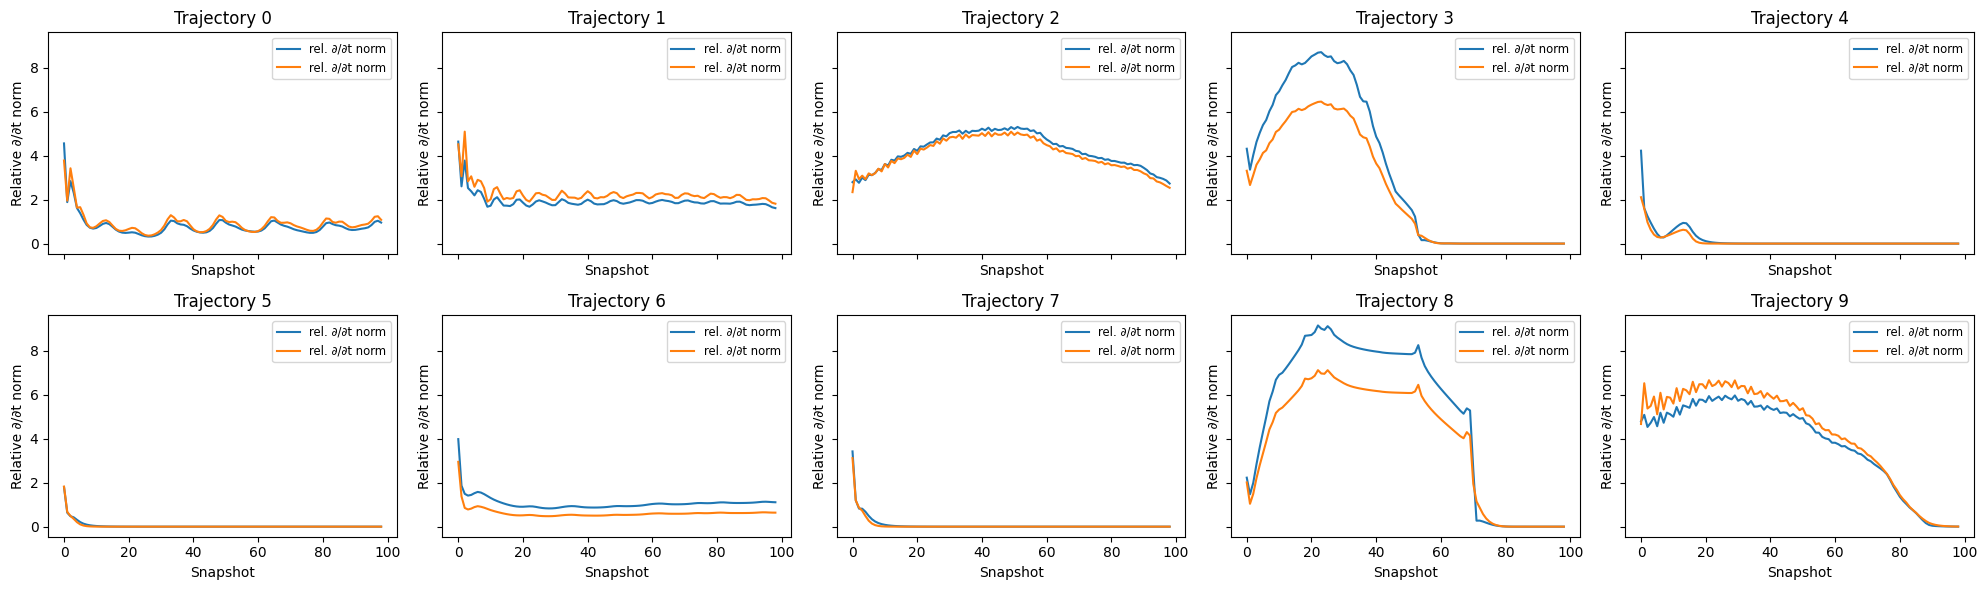

In [27]:
df_sub = df.sample(10)
indices = df_sub.idx
d = ds.dataset["data"][indices.values]
stacked = np.stack([d[:,:,:,0::2], d[:,:,:,1::2]], axis=2)
stacked = stacked[:,:,:,1:-1,1:-1]
stacked.shape

data = stacked

# Compute discrete time derivative
dt_data = np.diff(data, axis=1)  # shape: [B, n_snap-1, Nx, 2Ny]

dt_norm = np.linalg.norm(dt_data, axis=(3, 4))  # [B, n_snap-1]

n_traj = 10
n_cols = 5
n_rows = int(np.ceil(n_traj / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(n_traj):
    ax = axes[i]
    ax.plot(dt_norm[i], label="rel. ∂/∂t norm")
    # ax.axvline(settling_times[i] - 1, color='r', linestyle='--', label="settling time")
    ax.set_title(f"Trajectory {i}")
    ax.set_xlabel("Snapshot")
    ax.set_ylabel("Relative ∂/∂t norm")
    # ax.set_yscale('log')
    ax.legend(fontsize="small")

# Hide unused axes
for j in range(n_traj, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [20]:
i = 5529
make_animation(ds.get_data(i), i, ".")

MovieWriter ffmpeg unavailable; using Pillow instead.


In [6]:
df_sub = df[(df.A < 1) & (df.ratio_b_a.between(2,3))]

In [12]:
df['pattern_class'].unique()

array([0, 2, 1])

3.428484 1.1745105416854795


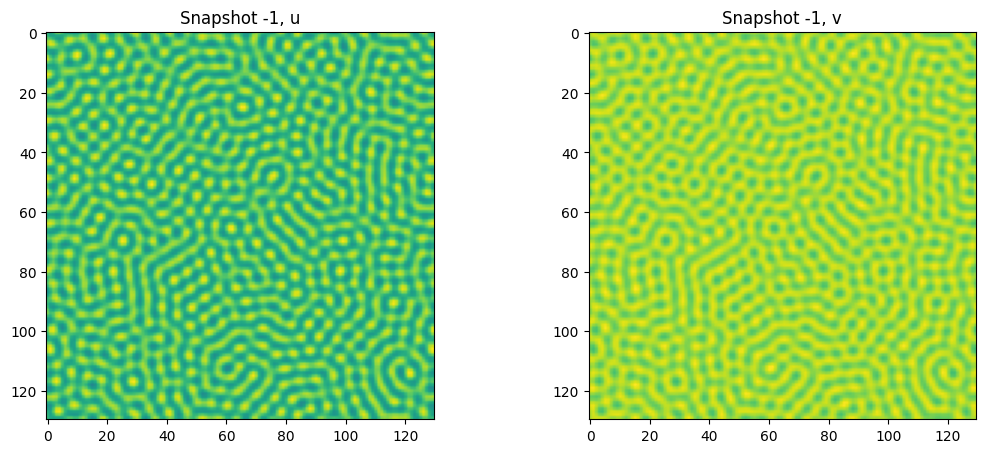

4.993053 1.8088029508198693


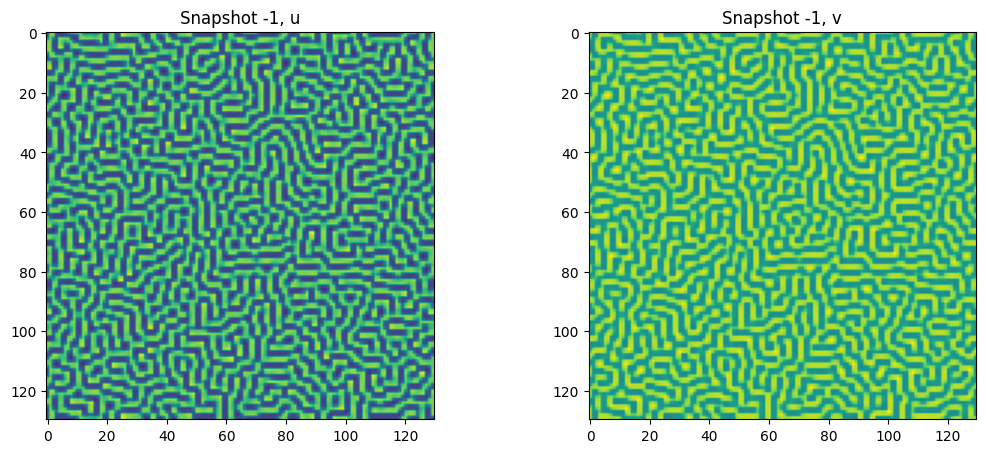

3.9158742 1.6256481885960483


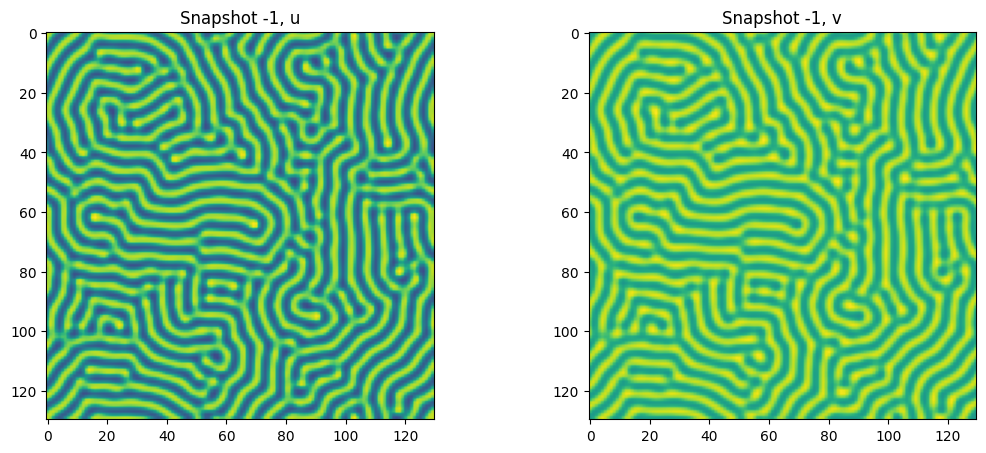

3.7010531 1.6727403884045868


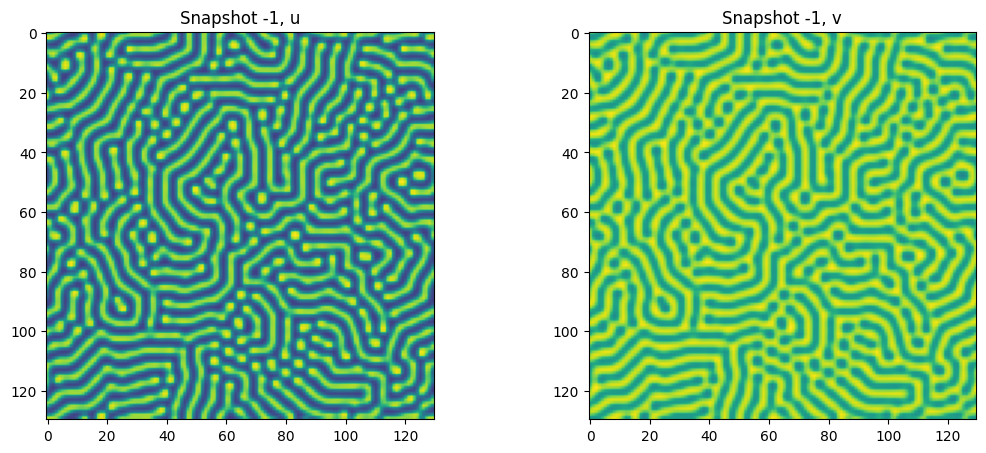

3.446317 1.8804859216375047


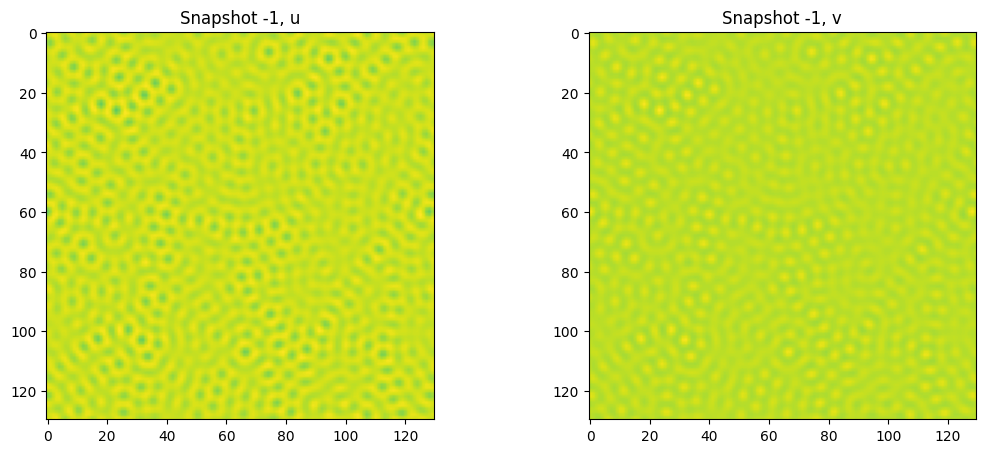

In [7]:
df_sub = df[df.pattern_class == 1]
for i, row in df_sub.sample(5).iterrows():
    d = ds.get_data(i)
    print(row["A"], row["ratio_b_a"], flush=True)
    plot(d, 0, np.max(d))
    plt.show()

In [ ]:
indices = [102, 1104, 1814, 2547, 3365, 3466, 6760, 7333, 7698, 9312, 9520, 10686]
df_sel = df.iloc[indices]

<Axes: xlabel='ratio_b_a', ylabel='A'>

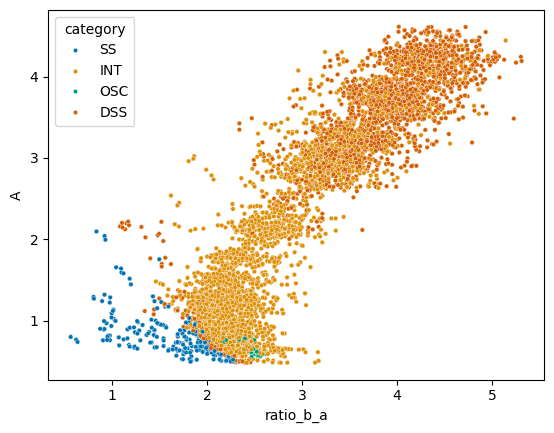

In [ ]:
colorblind_palette = sns.color_palette("colorblind")

# Define a fixed hue mapping
categories = ["SS", "INT", "OSC", "DSS"]
hue_mapping = {cat: colorblind_palette[i] for i, cat in enumerate(categories)}

sns.scatterplot(df, x="ratio_b_a", y="A", hue="category", palette=hue_mapping, hue_order=categories, marker="o", s=10)
